# Notebook 02 — Portfolio Risk Attribution (Indian Portfolio)

## Objective
Build an **equal-weighted Indian equity portfolio** and attribute total portfolio risk back to each position using the covariance matrix.

## Portfolio
| Stock | Ticker | Sector |
|---|---|---|
| Reliance Industries | RELIANCE.NS | Energy / Conglomerate |
| Tata Consultancy Services | TCS.NS | IT Services |
| HDFC Bank | HDFCBANK.NS | Banking |
| Infosys | INFY.NS | IT Services |
| ITC | ITC.NS | FMCG |

## Key Concepts

**Portfolio Variance:** $\sigma_p^2 = w^T \Sigma w$

**Marginal Contribution to Risk (MCR):** $MCR_i = \frac{(\Sigma w)_i}{\sigma_p}$

**Component Contribution to Risk (CCR):** $CCR_i = w_i \cdot MCR_i$

**% Risk Contribution:** $\%CCR_i = \frac{CCR_i}{\sigma_p} \times 100$

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme — applied once globally ───────────────────────────────────────
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor'  : '#0D0D0D',
    'axes.facecolor'    : '#0D0D0D',
    'axes.edgecolor'    : '#444444',
    'axes.labelcolor'   : '#CCCCCC',
    'axes.titlecolor'   : '#FFFFFF',
    'xtick.color'       : '#AAAAAA',
    'ytick.color'       : '#AAAAAA',
    'grid.color'        : '#2A2A2A',
    'grid.linewidth'    : 0.6,
    'legend.facecolor'  : '#1A1A1A',
    'legend.edgecolor'  : '#444444',
    'legend.labelcolor' : '#CCCCCC',
    'text.color'        : '#FFFFFF',
    'font.size'         : 10,
})

# ── Portfolio Configuration ───────────────────────────────────────────────────
TICKERS      = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ITC.NS']
LABELS       = ['RELIANCE', 'TCS', 'HDFCBANK', 'INFY', 'ITC']
WEIGHTS      = np.array([0.20, 0.20, 0.20, 0.20, 0.20])
START        = '2018-01-01'
END          = '2024-01-01'

COLORS       = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300']
STOCK_COLORS = dict(zip(LABELS, COLORS))

print(f"Portfolio : {dict(zip(LABELS, WEIGHTS))}")
print(f"Period    : {START} → {END}")

Portfolio : {'RELIANCE': np.float64(0.2), 'TCS': np.float64(0.2), 'HDFCBANK': np.float64(0.2), 'INFY': np.float64(0.2), 'ITC': np.float64(0.2)}
Period    : 2018-01-01 → 2024-01-01


## 2. Download Data

In [2]:
raw         = yf.download(TICKERS, start=START, end=END)['Close']
raw.columns = LABELS
returns     = np.log(raw / raw.shift(1)).dropna()

print(f"Shape      : {returns.shape}")
print(f"Date range : {returns.index[0].date()} → {returns.index[-1].date()}")

ind_vols = returns.std() * np.sqrt(252)
print(f"\nIndividual Annualised Volatilities:")
for label in LABELS:
    print(f"  {label:12s} : {ind_vols[label]*100:.2f}%")

[*********************100%***********************]  5 of 5 completed

Shape      : (1480, 5)
Date range : 2018-01-02 → 2023-12-29

Individual Annualised Volatilities:
  RELIANCE     : 25.46%
  TCS          : 28.18%
  HDFCBANK     : 25.41%
  INFY         : 29.74%
  ITC          : 24.94%


## 3. Covariance Matrix & Portfolio Volatility

In [3]:
cov_matrix = returns.cov() * 252
port_var   = WEIGHTS @ cov_matrix.values @ WEIGHTS
port_vol   = np.sqrt(port_var)

print(f"Portfolio Annualised Volatility : {port_vol*100:.2f}%")
print(f"Portfolio Annualised Variance   : {port_var*100:.4f}%")
print(f"\nCorrelation Matrix:")
print(returns.corr().round(3).to_string())

Portfolio Annualised Volatility : 18.17%
Portfolio Annualised Variance   : 3.3026%

Correlation Matrix:
          RELIANCE    TCS  HDFCBANK   INFY    ITC
RELIANCE     1.000  0.312     0.314  0.414  0.276
TCS          0.312  1.000     0.200  0.300  0.620
HDFCBANK     0.314  0.200     1.000  0.285  0.205
INFY         0.414  0.300     0.285  1.000  0.322
ITC          0.276  0.620     0.205  0.322  1.000


## 4. Risk Attribution

In [4]:
def risk_attribution(weights, cov_matrix):
    port_var = weights @ cov_matrix @ weights
    port_vol = np.sqrt(port_var)
    mcr      = (cov_matrix @ weights) / port_vol
    ccr      = weights * mcr
    pct_ccr  = ccr / port_vol * 100
    return mcr, ccr, pct_ccr, port_vol

mcr, ccr, pct_ccr, port_vol = risk_attribution(WEIGHTS, cov_matrix.values)

attribution_df = pd.DataFrame({
    'Weight %'            : WEIGHTS * 100,
    'Indiv. Vol %'        : ind_vols.values * 100,
    'MCR'                 : mcr,
    'CCR'                 : ccr,
    '% Risk Contribution' : pct_ccr
}, index=LABELS).round(4)

print("── Risk Attribution Table — Indian Portfolio ─────────────────────")
print(attribution_df.to_string())
print(f"\nTotal Risk Contribution : {pct_ccr.sum():.2f}%")

── Risk Attribution Table — Indian Portfolio ─────────────────────
          Weight %  Indiv. Vol %     MCR     CCR  % Risk Contribution
RELIANCE      20.0       25.4629  0.1722  0.0344              18.9474
TCS           20.0       28.1790  0.2035  0.0407              22.3965
HDFCBANK      20.0       25.4135  0.1472  0.0294              16.2007
INFY          20.0       29.7420  0.2095  0.0419              23.0598
ITC           20.0       24.9360  0.1762  0.0352              19.3956

Total Risk Contribution : 100.00%


## 5. Visualisations

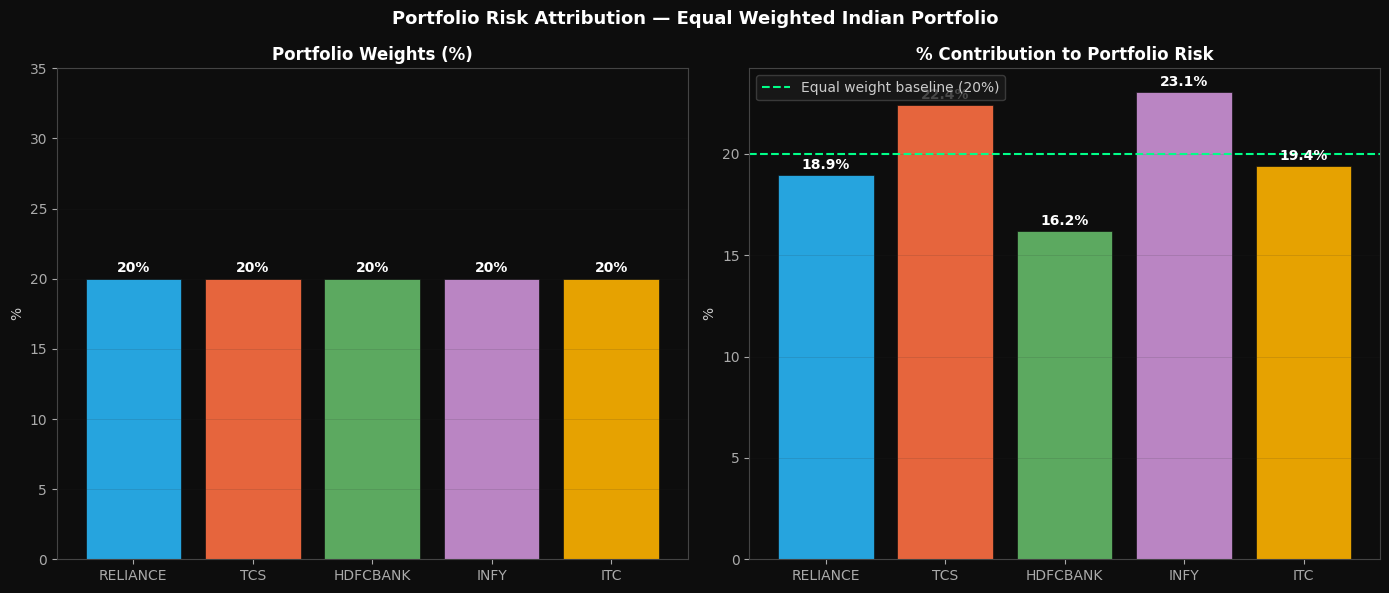

In [5]:
# ── Plot 1: Weight vs Risk Contribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Portfolio Risk Attribution — Equal Weighted Indian Portfolio',
             fontsize=13, fontweight='bold', color='white')
fig.patch.set_facecolor('#0D0D0D')

bar_colors = [STOCK_COLORS[l] for l in LABELS]

# Weights
axes[0].bar(LABELS, WEIGHTS * 100, color=bar_colors,
            alpha=0.9, edgecolor='#0D0D0D', linewidth=0.5)
axes[0].set_title('Portfolio Weights (%)', fontweight='bold', color='white')
axes[0].set_ylabel('%', color='#CCCCCC')
axes[0].set_ylim(0, 35)
axes[0].grid(True, axis='y', alpha=0.15)
for i, v in enumerate(WEIGHTS * 100):
    axes[0].text(i, v + 0.5, f'{v:.0f}%',
                 ha='center', fontweight='bold', color='white')

# Risk contribution
axes[1].bar(LABELS, pct_ccr, color=bar_colors,
            alpha=0.9, edgecolor='#0D0D0D', linewidth=0.5)
axes[1].axhline(20, color='#00FF88', linewidth=1.5,
                linestyle='--', label='Equal weight baseline (20%)')
axes[1].set_title('% Contribution to Portfolio Risk',
                  fontweight='bold', color='white')
axes[1].set_ylabel('%', color='#CCCCCC')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.15)
for i, v in enumerate(pct_ccr):
    axes[1].text(i, v + 0.3, f'{v:.1f}%',
                 ha='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()


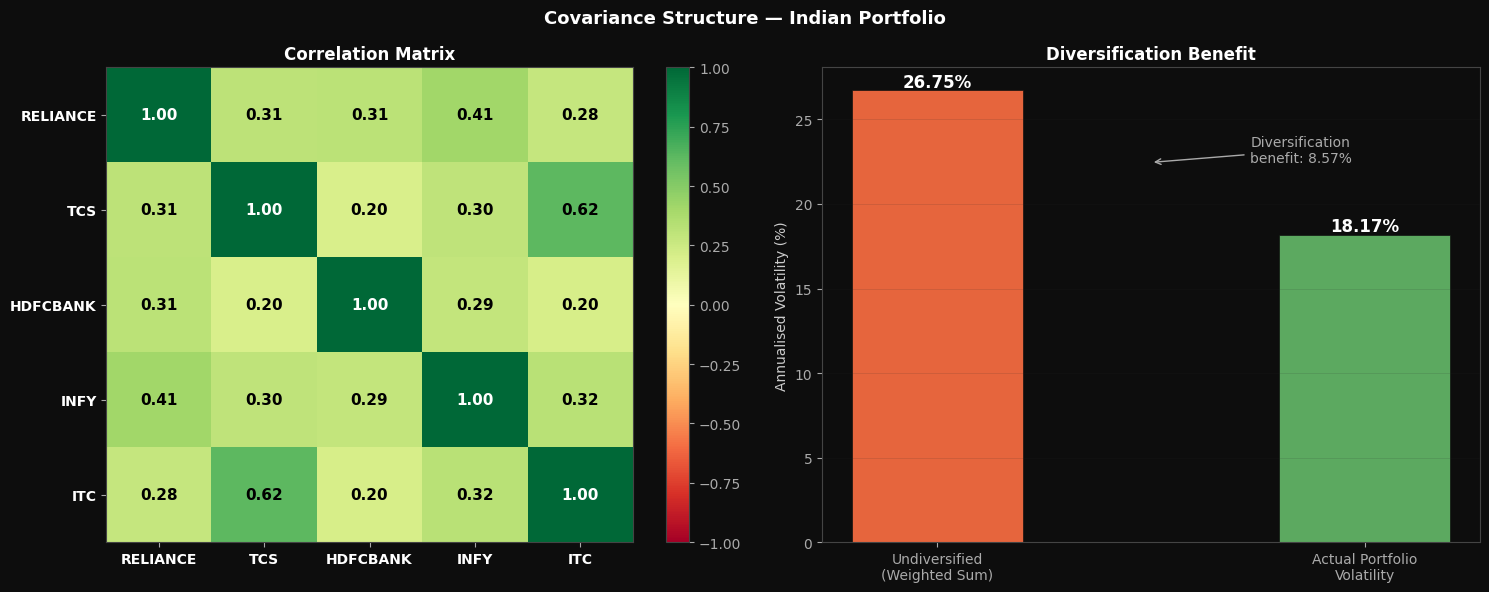

In [6]:
# ── Plot 2: Correlation heatmap + Diversification benefit ─────────────────────
corr = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Covariance Structure — Indian Portfolio',
             fontsize=13, fontweight='bold', color='white')
fig.patch.set_facecolor('#0D0D0D')

# Correlation heatmap
ax = axes[0]
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(LABELS)))
ax.set_yticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, fontweight='bold', color='white')
ax.set_yticklabels(LABELS, fontweight='bold', color='white')
ax.set_title('Correlation Matrix', fontweight='bold', color='white')
plt.colorbar(im, ax=ax)
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}',
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='black' if 0.2 < abs(corr.values[i,j]) < 0.7 else 'white')

# Diversification benefit
ax2          = axes[1]
weighted_vol = np.sum(WEIGHTS * ind_vols.values) * 100
actual_vol   = port_vol * 100
diversif_ben = weighted_vol - actual_vol

bars = ax2.bar(
    ['Undiversified\n(Weighted Sum)', 'Actual Portfolio\nVolatility'],
    [weighted_vol, actual_vol],
    color=['#FF7043', '#66BB6A'], alpha=0.9,
    edgecolor='#0D0D0D', linewidth=0.5, width=0.4
)
ax2.set_title('Diversification Benefit', fontweight='bold', color='white')
ax2.set_ylabel('Annualised Volatility (%)', color='#CCCCCC')
ax2.grid(True, axis='y', alpha=0.15)
for bar, v in zip(bars, [weighted_vol, actual_vol]):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.2,
             f'{v:.2f}%', ha='center', fontweight='bold',
             fontsize=12, color='white')
ax2.annotate(
    f'Diversification\nbenefit: {diversif_ben:.2f}%',
    xy=(0.5, (weighted_vol + actual_vol)/2),
    xytext=(0.85, (weighted_vol + actual_vol)/2),
    fontsize=10, ha='center', color='#AAAAAA',
    arrowprops=dict(arrowstyle='->', color='#AAAAAA')
)

plt.tight_layout()
plt.show()


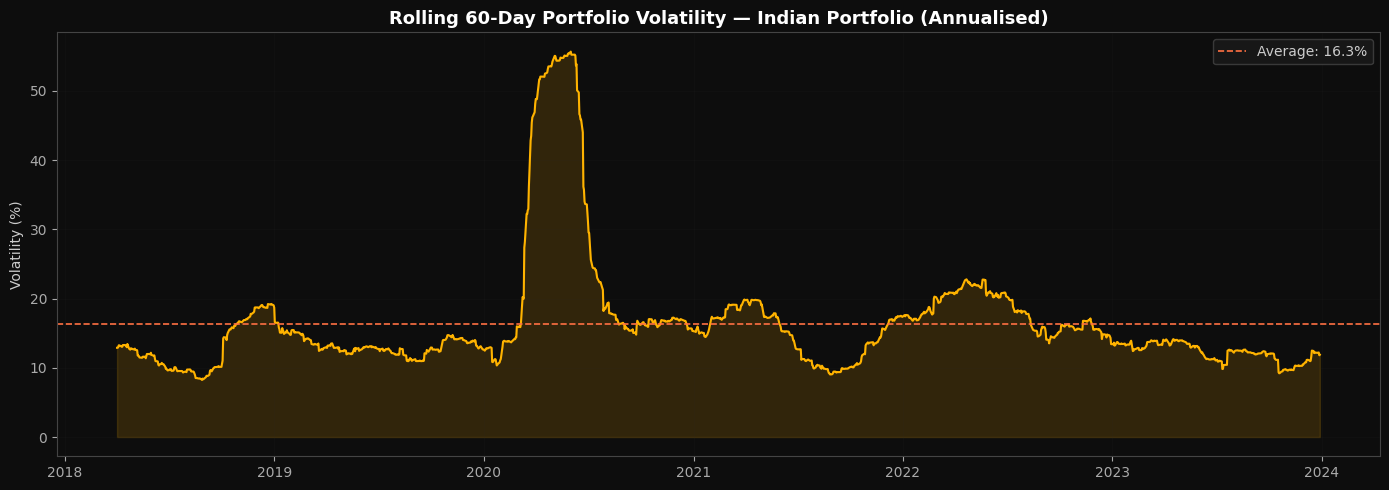

In [7]:
# ── Plot 3: Rolling portfolio volatility ──────────────────────────────────────
port_returns = (returns * WEIGHTS).sum(axis=1)
rolling_vol  = port_returns.rolling(window=60).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0D0D0D')

ax.plot(rolling_vol.index, rolling_vol.values,
        color='#FFB300', linewidth=1.5)
ax.fill_between(rolling_vol.index, rolling_vol.values,
                alpha=0.15, color='#FFB300')
ax.axhline(rolling_vol.mean(), color='#FF7043', linewidth=1.2,
           linestyle='--', label=f'Average: {rolling_vol.mean():.1f}%')
ax.set_title('Rolling 60-Day Portfolio Volatility — Indian Portfolio (Annualised)',
             fontsize=13, fontweight='bold', color='white')
ax.set_ylabel('Volatility (%)', color='#CCCCCC')
ax.legend()
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()


## 6. US vs India Portfolio — Risk Comparison

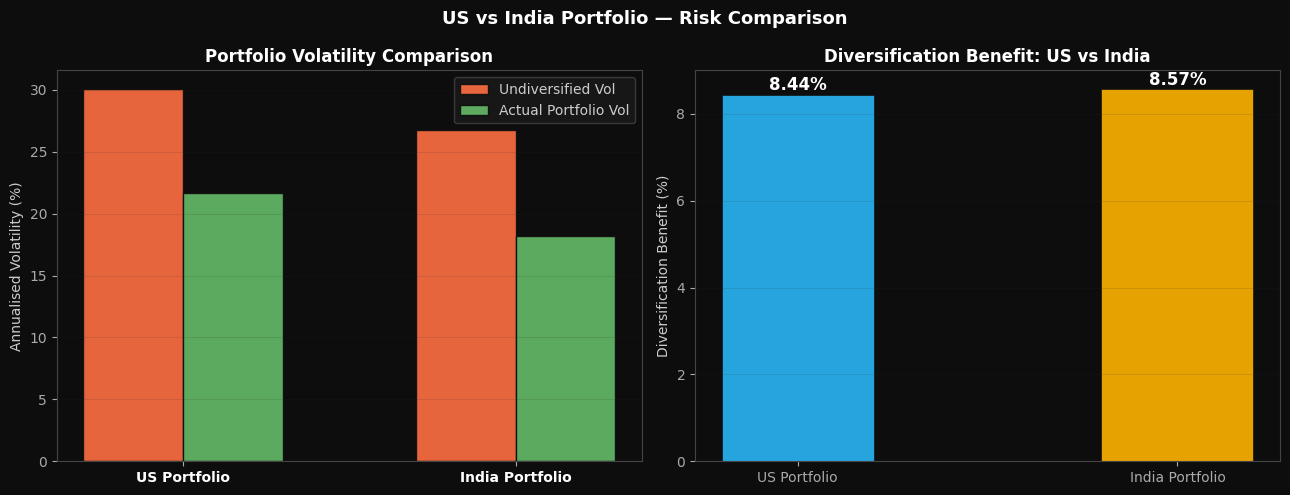

In [8]:
# US portfolio numbers from Notebook 02 US results
us_port_vol     = 21.63
us_weighted_vol = 30.07
us_diversif     = us_weighted_vol - us_port_vol
india_port_vol  = actual_vol
india_weighted_v= weighted_vol
india_diversif  = diversif_ben

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('US vs India Portfolio — Risk Comparison',
             fontsize=13, fontweight='bold', color='white')
fig.patch.set_facecolor('#0D0D0D')

# Volatility comparison
ax = axes[0]
x  = np.arange(2)
w  = 0.3
ax.bar(x - w/2, [us_weighted_vol,  india_weighted_v], w,
       label='Undiversified Vol',
       color='#FF7043', alpha=0.9, edgecolor='#0D0D0D')
ax.bar(x + w/2, [us_port_vol, india_port_vol], w,
       label='Actual Portfolio Vol',
       color='#66BB6A', alpha=0.9, edgecolor='#0D0D0D')
ax.set_xticks(x)
ax.set_xticklabels(['US Portfolio', 'India Portfolio'],
                   fontweight='bold', color='white')
ax.set_ylabel('Annualised Volatility (%)', color='#CCCCCC')
ax.set_title('Portfolio Volatility Comparison', fontweight='bold', color='white')
ax.legend()
ax.grid(True, axis='y', alpha=0.15)

# Diversification benefit
ax2  = axes[1]
bars = ax2.bar(
    ['US Portfolio', 'India Portfolio'],
    [us_diversif, india_diversif],
    color=['#29B6F6', '#FFB300'], alpha=0.9,
    edgecolor='#0D0D0D', linewidth=0.5, width=0.4
)
ax2.set_ylabel('Diversification Benefit (%)', color='#CCCCCC')
ax2.set_title('Diversification Benefit: US vs India',
              fontweight='bold', color='white')
ax2.grid(True, axis='y', alpha=0.15)
for bar, v in zip(bars, [us_diversif, india_diversif]):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.1,
             f'{v:.2f}%', ha='center',
             fontweight='bold', fontsize=12, color='white')

plt.tight_layout()
plt.show()


## 7. Key Findings

In [9]:
print("=" * 62)
print("  PORTFOLIO RISK ATTRIBUTION — INDIAN PORTFOLIO FINDINGS")
print("=" * 62)
print(f"\nPortfolio Volatility (annualised) : {port_vol*100:.2f}%")
print(f"Weighted-sum Volatility           : {weighted_vol:.2f}%")
print(f"Diversification Benefit           : {diversif_ben:.2f}%")

print("\nRisk Attribution:")
for i, label in enumerate(LABELS):
    diff = pct_ccr[i] - 20
    flag = '▲ Over-contributing'  if diff >  2 else \
           '▼ Under-contributing' if diff < -2 else '≈ Neutral'
    print(f"  {label:12s} : {pct_ccr[i]:.1f}%  [{flag}]")

top_risk = LABELS[np.argmax(pct_ccr)]
best_div = LABELS[np.argmin(pct_ccr)]
print(f"\nBiggest risk driver : {top_risk} ({pct_ccr[np.argmax(pct_ccr)]:.1f}%)")
print(f"Best diversifier    : {best_div} ({pct_ccr[np.argmin(pct_ccr)]:.1f}%)")

print("\nKey Insight — TCS vs INFY Correlation:")
tcs_infy_corr = returns.corr().loc['TCS', 'INFY']
print(f"  TCS & INFY correlation : {tcs_infy_corr:.3f}")
print(f"  Both are USD-revenue IT stocks. Their correlation")
print(f"  means holding both provides limited diversification.")

print("\nUS vs India Comparison:")
print(f"  US diversification benefit   : {us_diversif:.2f}%")
print(f"  India diversification benefit : {india_diversif:.2f}%")
if india_diversif < us_diversif:
    print("  → Indian portfolio benefits LESS from diversification")
    print("    because sectors are more correlated domestically.")
else:
    print("  → Indian portfolio benefits MORE from diversification")
    print("    due to greater sector heterogeneity.")
print("=" * 62)

  PORTFOLIO RISK ATTRIBUTION — INDIAN PORTFOLIO FINDINGS

Portfolio Volatility (annualised) : 18.17%
Weighted-sum Volatility           : 26.75%
Diversification Benefit           : 8.57%

Risk Attribution:
  RELIANCE     : 18.9%  [≈ Neutral]
  TCS          : 22.4%  [▲ Over-contributing]
  HDFCBANK     : 16.2%  [▼ Under-contributing]
  INFY         : 23.1%  [▲ Over-contributing]
  ITC          : 19.4%  [≈ Neutral]

Biggest risk driver : INFY (23.1%)
Best diversifier    : HDFCBANK (16.2%)

Key Insight — TCS vs INFY Correlation:
  TCS & INFY correlation : 0.300
  Both are USD-revenue IT stocks. Their correlation
  means holding both provides limited diversification.

US vs India Comparison:
  US diversification benefit   : 8.44%
  India diversification benefit : 8.57%
  → Indian portfolio benefits MORE from diversification
    due to greater sector heterogeneity.
